In [2]:
df.to_csv('SuperStore Sale eda_cleaned.csv', index=False)
print("Saved")

NameError: name 'df' is not defined

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/marjanabdi/superstore-sale-dataset/SuperStoreOrders.csv


# About Dataset

"Superstore Sales" generally refers to the sales data and performance of a superstore or a large retail store that offers a wide range of products and merchandise. These superstores are typically known for their extensive inventory, competitive pricing, and one-stop shopping experience.

Analyzing superstore sales data is essential for store owners, managers, and analysts to understand the store's performance, identify trends, and make informed business decisions. Here are some key aspects of superstore sales analysis:

Sales Revenue: Tracking the total sales revenue over time provides insights into the overall financial performance of the superstore. It helps identify peak seasons and periods of high or low sales.

Sales by Product Category: Analyzing sales by product category (e.g., electronics, apparel, home goods) helps understand which categories are driving revenue and which may require improvement.

Sales by Region: Superstores often have multiple locations. Analyzing sales by region helps identify the best-performing stores and areas for expansion or improvement.

Sales by Customer Segments: Understanding sales patterns among different customer segments can inform targeted marketing strategies and customer engagement.

Sales Trends: Identifying sales trends over time, such as monthly or seasonal variations, can help in inventory management and marketing planning.

Product Performance: Analyzing individual product sales can help identify popular products, slow-moving items, and potential stockouts.

Customer Behavior: Studying customer behavior, such as purchase frequency, average transaction value, and repeat purchases, provides insights into customer preferences and loyalty.

Promotions and Discounts: Evaluating the impact of promotions and discounts on sales can help optimize marketing strategies.

Sales Forecasting: Using historical sales data, superstore owners and managers can forecast future sales, plan inventory levels, and make data-driven decisions.

To conduct thorough sales analysis, superstores often use data visualization tools, spreadsheets, or specialized retail analytics software. These tools help present the data in a visually appealing and easy-to-understand format, enabling better decision-making and strategic planning. Additionally, by integrating sales data with other metrics like profitability, inventory turnover, and customer satisfaction, superstore owners can gain a comprehensive view of their business performance.

# Import Important Libraraies

In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
sns.set()

import datetime
import plotly.express as px
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from zipfile import ZipFile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer

# Import Data

In [3]:
df = pd.read_csv('/kaggle/input/datasets/marjanabdi/superstore-sale-dataset/SuperStoreOrders.csv')

# Data Overview

In [4]:
df.head(5)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [5]:
df.tail(5)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
51285,CA-2014-115427,31-12-2014,4/1/2015,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,31-12-2014,5/1/2015,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,31-12-2014,2/1/2015,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,31-12-2014,6/1/2015,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014
51289,CA-2014-156720,31-12-2014,4/1/2015,Standard Class,Jill Matthias,Consumer,Colorado,United States,US,West,...,Office Supplies,Fasteners,Bagged Rubber Bands,3,3,0.2,-0.6048,0.17,Medium,2014


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

# ****Clean and Normalizing Data****

******Change data type of order date and ship date to datetime******

In [7]:
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], format='mixed', dayfirst=True)

In [8]:
for col in ['sales', 'profit', 'shipping_cost']:
    df[col] = pd.to_numeric(
        df[col].astype(str)
              .str.replace('$', '', regex=False)
              .str.replace(',', '', regex=False)
              .str.strip(),
        errors='coerce'
    )

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  int64         
 15  qu

In [10]:
df.describe()

,order_date,ship_date,sales,quantity,discount,profit,shipping_cost,year
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,2013-05-11 21:26:49.155780864,2013-05-15 20:42:42.745174528,246.498440,3.476545,0.142908,28.641740,26.375915,2012.777208
min,2011-01-01 00:00:00,2011-01-03 00:00:00,0.000000,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2012-06-19 00:00:00,2012-06-23 00:00:00,31.000000,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,2013-07-08 00:00:00,2013-07-12 00:00:00,85.000000,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,2014-05-22 00:00:00,2014-05-26 00:00:00,251.000000,5.000000,0.200000,36.810000,24.450000,2014.000000
max,2014-12-31 00:00:00,2015-01-07 00:00:00,22638.000000,14.000000,0.850000,8399.976000,933.570000,2014.000000
std,NaN,NaN,487.567175,2.278766,0.212280,174.424113,57.296804,1.098931


***_Changing order_date to year,Month, Days seperately_***

In [11]:
df['OrderY']=df['order_date'].dt.year
df['OrderM']=df['order_date'].dt.month
df['OrderD']=df['order_date'].dt.day
#df['ShippingY']=df['ship_date'].dt.year
#df['ShippingM']=df['ship_date'].dt.month
#df['ShippingD']=df['ship_date'].dt.day

In [12]:
df['Days_took']=(df['ship_date']-df['order_date']).dt.days

In [13]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,quantity,discount,profit,shipping_cost,order_priority,year,OrderY,OrderM,OrderD,Days_took
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,2,0.0,106.140,35.46,Medium,2011,2011,1,1,5
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,3,0.1,36.036,9.72,Medium,2011,2011,1,1,7
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,4,0.0,29.640,8.17,High,2011,2011,1,1,4
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,3,0.5,-26.055,4.82,High,2011,2011,1,1,4
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,5,0.1,37.770,4.70,Medium,2011,2011,1,1,7


In [14]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
OrderY            0
OrderM            0
OrderD            0
Days_took         0
dtype: int64

In [15]:
df[df.duplicated()]

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,quantity,discount,profit,shipping_cost,order_priority,year,OrderY,OrderM,OrderD,Days_took


# ****Adding column Profitability as profit margin****

In [16]:
df['Profitability']=(df['profit']/df['sales'])*100

In [17]:
df.head(5)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,discount,profit,shipping_cost,order_priority,year,OrderY,OrderM,OrderD,Days_took,Profitability
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,0.0,106.140,35.46,Medium,2011,2011,1,1,5,26.014706
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,0.1,36.036,9.72,Medium,2011,2011,1,1,7,30.030000
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,0.0,29.640,8.17,High,2011,2011,1,1,4,44.909091
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,0.5,-26.055,4.82,High,2011,2011,1,1,4,-57.900000
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,0.1,37.770,4.70,Medium,2011,2011,1,1,7,33.131579


In [18]:
df.nunique()

order_id          25035
order_date         1430
ship_date          1464
ship_mode             4
customer_name       795
segment               3
state              1094
country             147
market                7
region               13
product_id        10292
category              3
sub_category         17
product_name       3788
sales              2246
quantity             14
discount             27
profit            24575
shipping_cost     10037
order_priority        4
year                  4
OrderY                4
OrderM               12
OrderD               31
Days_took             8
Profitability     28797
dtype: int64

****Finding Min,Mean,Median,std,Sum,Count of Sales by category****

In [19]:
g=df.groupby('category')['sales']
df.groupby('category')['sales'].agg(['sum','mean','median','std','count'])

,sum,mean,median,std,count
category,,,,,
Furniture,4110884,416.249899,220.0,553.068445,9876
Office Supplies,3787330,121.105426,46.0,299.323785,31273
Technology,4744691,467.872103,260.0,708.974561,10141


In [20]:
# sales and proft base on market 
df.groupby('market')[['sales', 'profit']].sum().sort_values('profit', ascending=False)

,sales,profit
market,,
APAC,3585833,437577.57900
EU,2938139,372829.74150
US,2297354,286397.02170
LATAM,2164687,221643.48708
Africa,783776,88871.63100
EMEA,806184,43897.97100
Canada,66932,17817.39000


In [21]:
df.query("sales == 0")[['order_id', 'sales', 'profit', 'discount', 'quantity', 'Profitability']]

,order_id,sales,profit,discount,quantity,Profitability
40017,US-2014-102288,0,-1.11,0.8,1,-inf


In [22]:
# Go to your filtering cell above and change it to look like this:
df = df[df['order_date'] != 'order_date'].copy()
import numpy as np

# Use .loc[:, 'ColumnName'] instead of direct bracket assignment
df.loc[:, 'Profitability'] = df['Profitability'].replace([np.inf, -np.inf], np.nan)


In [23]:
#profit_margin base on market
df.groupby('market')['Profitability'].mean().sort_values(ascending=False)


market
Canada    24.743089
US        12.023244
EU        11.016694
APAC       6.958356
LATAM      6.171163
EMEA     -14.161834
Africa   -14.509152
Name: Profitability, dtype: float64

In [24]:
# base on category
df.groupby('category')[['sales', 'profit']].sum().sort_values('profit', ascending=False)

,sales,profit
category,,
Technology,4744691,663778.73318
Office Supplies,3787330,518473.83430
Furniture,4110884,286782.25380


# ****Which Market generate the highest sales profit?**** 

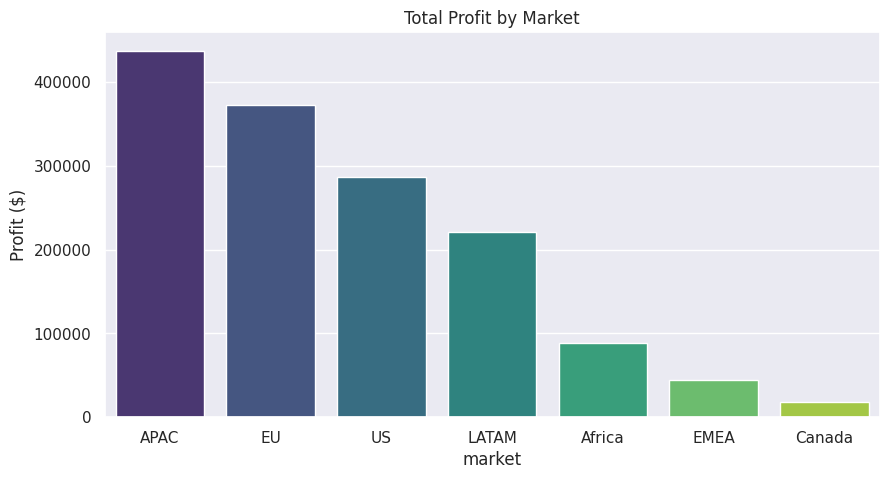

In [25]:
market_df = df.groupby('market')['profit'].sum().reset_index().sort_values('profit', ascending=False)

plt.figure(figsize=(10, 5))
# Pass 'market' to hue, and turn off the legend to keep it clean
sns.barplot(data=market_df, x='market', y='profit', hue='market', palette='viridis', legend=False)
plt.title('Total Profit by Market')
plt.ylabel('Profit ($)')
plt.show()

# Which Region generate the most profit and sale?

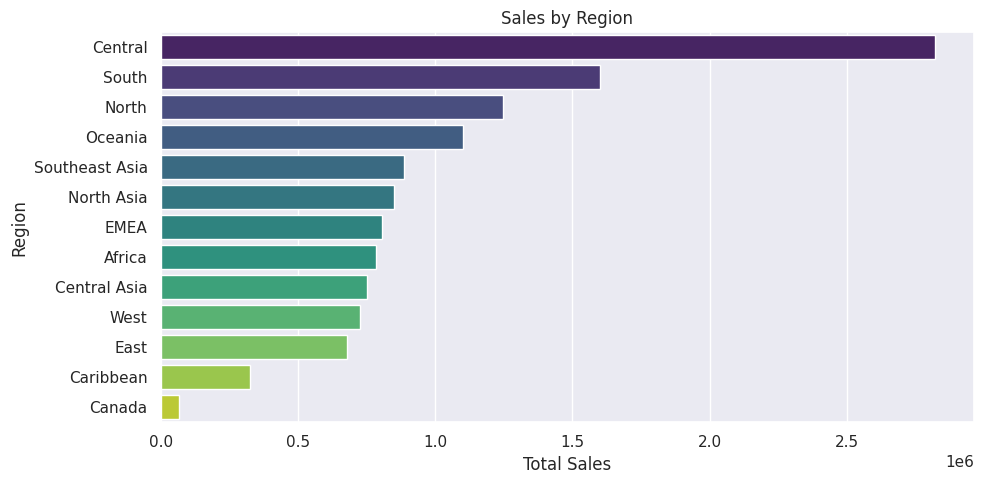

In [26]:
# 1. Prepare grouped data
region_sales = df.groupby('region', as_index=False)['sales'].sum().sort_values('sales', ascending=False).tail(13)

# 2. Set up the window size
plt.figure(figsize=(10, 5))

# 3. Plot with Seaborn using your 'palette' and assign 'hue' to clear warnings
sns.barplot(data=region_sales, x='sales', y='region', hue='region', palette='viridis', legend=False)

# 4. Final layout polish
plt.title("Sales by Region")
plt.xlabel("Total Sales")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

# What is the monthly sale trends in super store sales?

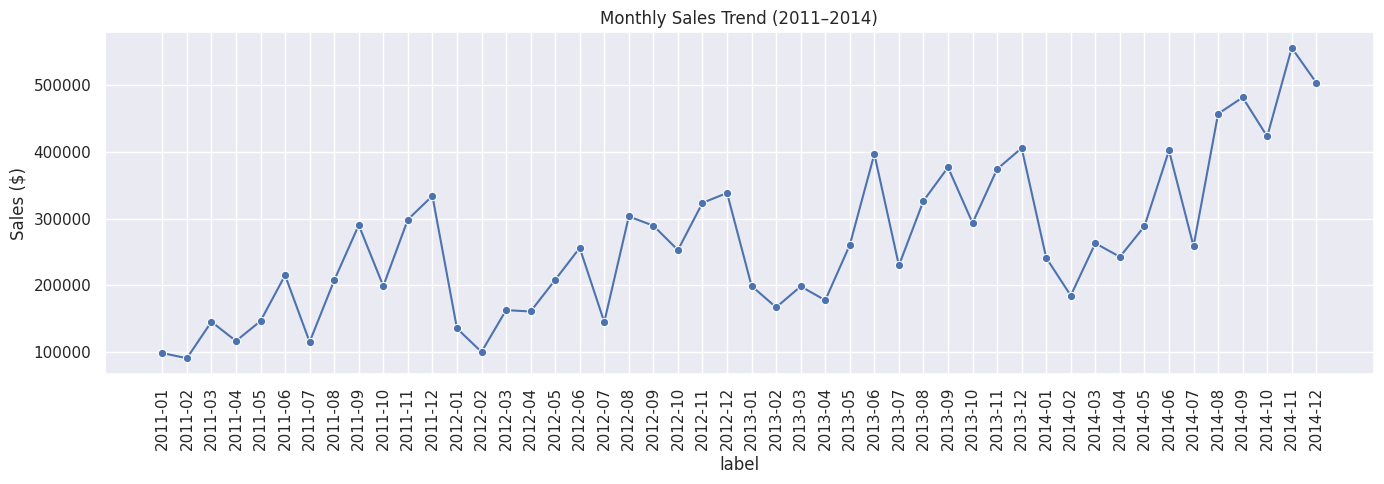

In [27]:
monthly_df = df.groupby(['OrderY', 'OrderM'])['sales'].sum().reset_index()
monthly_df = monthly_df.sort_values(['OrderY', 'OrderM'])
monthly_df['label'] = monthly_df['OrderY'].astype(str) + '-' + monthly_df['OrderM'].astype(str).str.zfill(2)

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_df, x='label', y='sales', marker='o')
plt.xticks(rotation=90)
plt.title('Monthly Sales Trend (2011–2014)')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

# Which product categories are the most and least profitable?

In [28]:
import plotly.express as px

# 1. Group using lowercase 'category' and 'sales'
category_sales = df.groupby('category', as_index=False)['sales'].sum().sort_values('sales', ascending=False)

# 2. Build the chart using lowercase names for data extraction
fig = px.bar(
    category_sales,
    x='category',       # Match your lowercase column
    y='sales',          # Match your lowercase column
    text_auto=".2s",
    title="Total Sales by Category",
    color="category"    # Match your lowercase column
)

# 3. Apply nice, polished labels for the display axis
fig.update_layout(
    xaxis_title='Category', # Visible chart label text can be capitalized
    yaxis_title="Total Sales",
    template="plotly_white",
    showlegend=False
)

# 4. Render the chart
fig.show()

# How do discount effect profitability across categories?

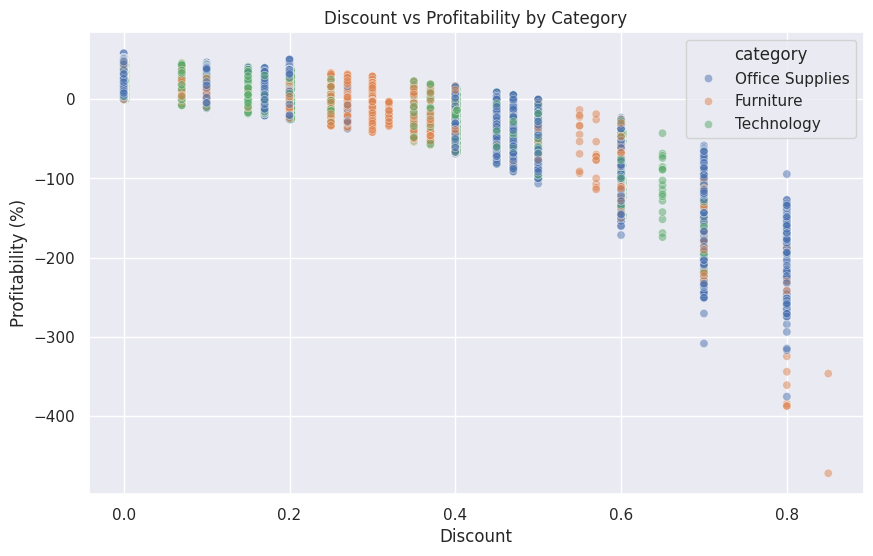

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='discount', y='Profitability', hue='category', alpha=0.5)
plt.title('Discount vs Profitability by Category')
plt.xlabel('Discount')
plt.ylabel('Profitability (%)')
plt.show()

# Where is the discount break-even point?

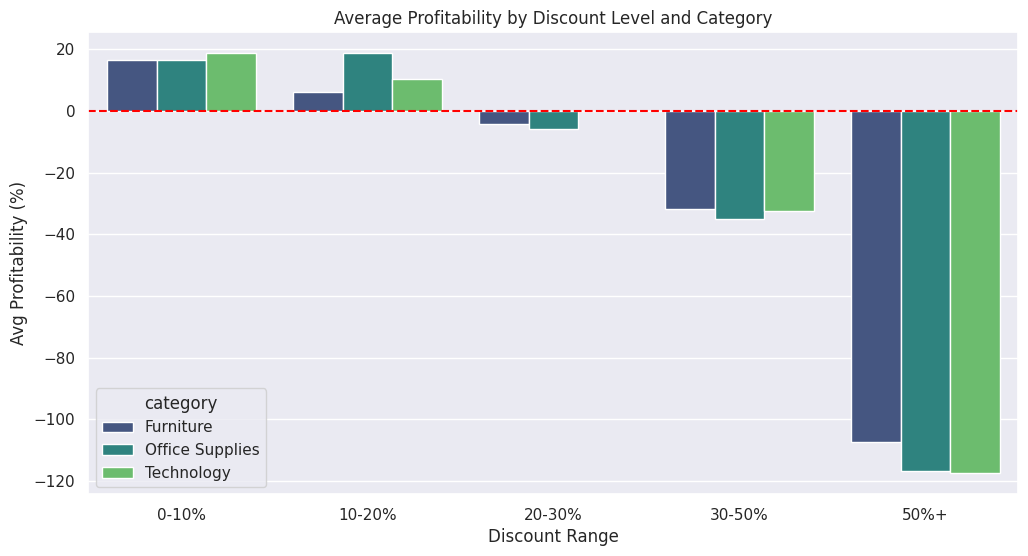

In [30]:
df['discount_bin'] = pd.cut(df['discount'],
    bins=[0, 0.1, 0.2, 0.3, 0.5, 0.9],
    labels=['0-10%', '10-20%', '20-30%', '30-50%', '50%+'])

bin_df = df.groupby(['discount_bin', 'category'], observed=True)['Profitability'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=bin_df, x='discount_bin', y='Profitability', hue='category', palette='viridis')
plt.axhline(0, color='red', linestyle='--')
plt.title('Average Profitability by Discount Level and Category')
plt.xlabel('Discount Range')
plt.ylabel('Avg Profitability (%)')
plt.show()

Discounts above 30% are loss-making on average across all categories, with 50%+ discounts averaging below −60% profitability — the company should cap discounts at 20%."

# what are the Top 10 profitable and less profitable products?

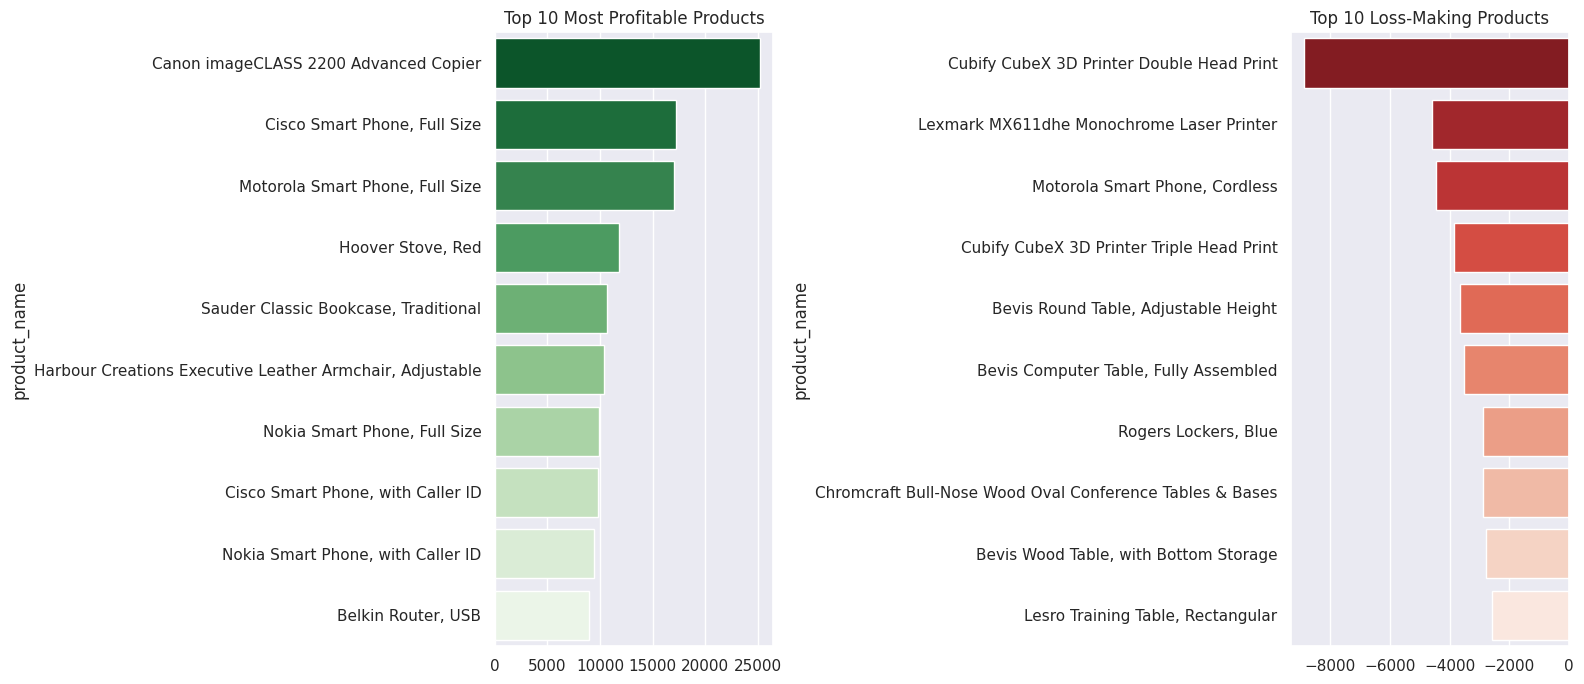

In [31]:
top_profit = df.groupby('product_name')['profit'].sum().sort_values(ascending=False).head(10)
top_loss = df.groupby('product_name')['profit'].sum().sort_values().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(x=top_profit.values, y=top_profit.index, ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10 Most Profitable Products')
sns.barplot(x=top_loss.values, y=top_loss.index, ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 10 Loss-Making Products')
plt.tight_layout()
plt.show()

# The Top 10 profitable costumers

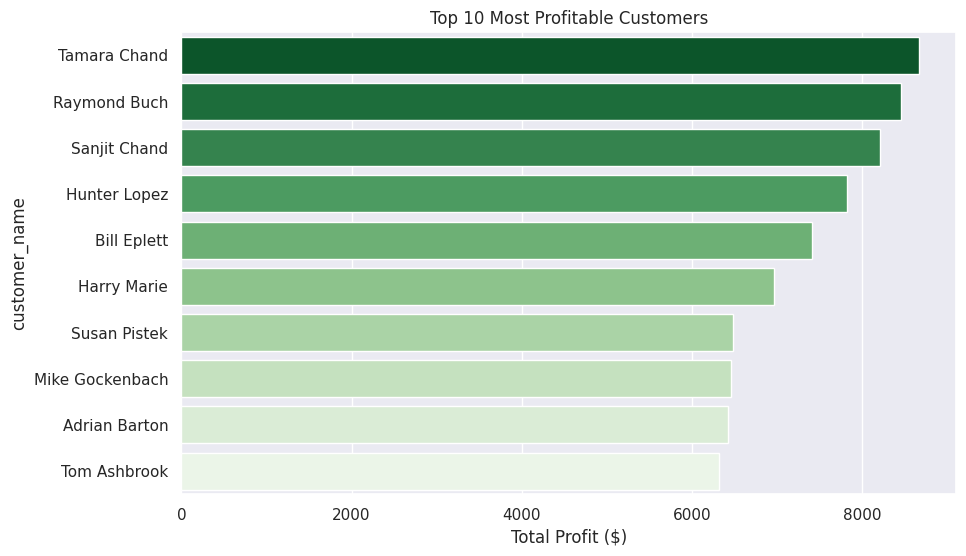

In [32]:
top_customers = df.groupby('customer_name')['profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_customers.values, y=top_customers.index, palette='Greens_r', legend=False)
plt.title('Top 10 Most Profitable Customers')
plt.xlabel('Total Profit ($)')
plt.show()

# which customers make vs lose the most money?

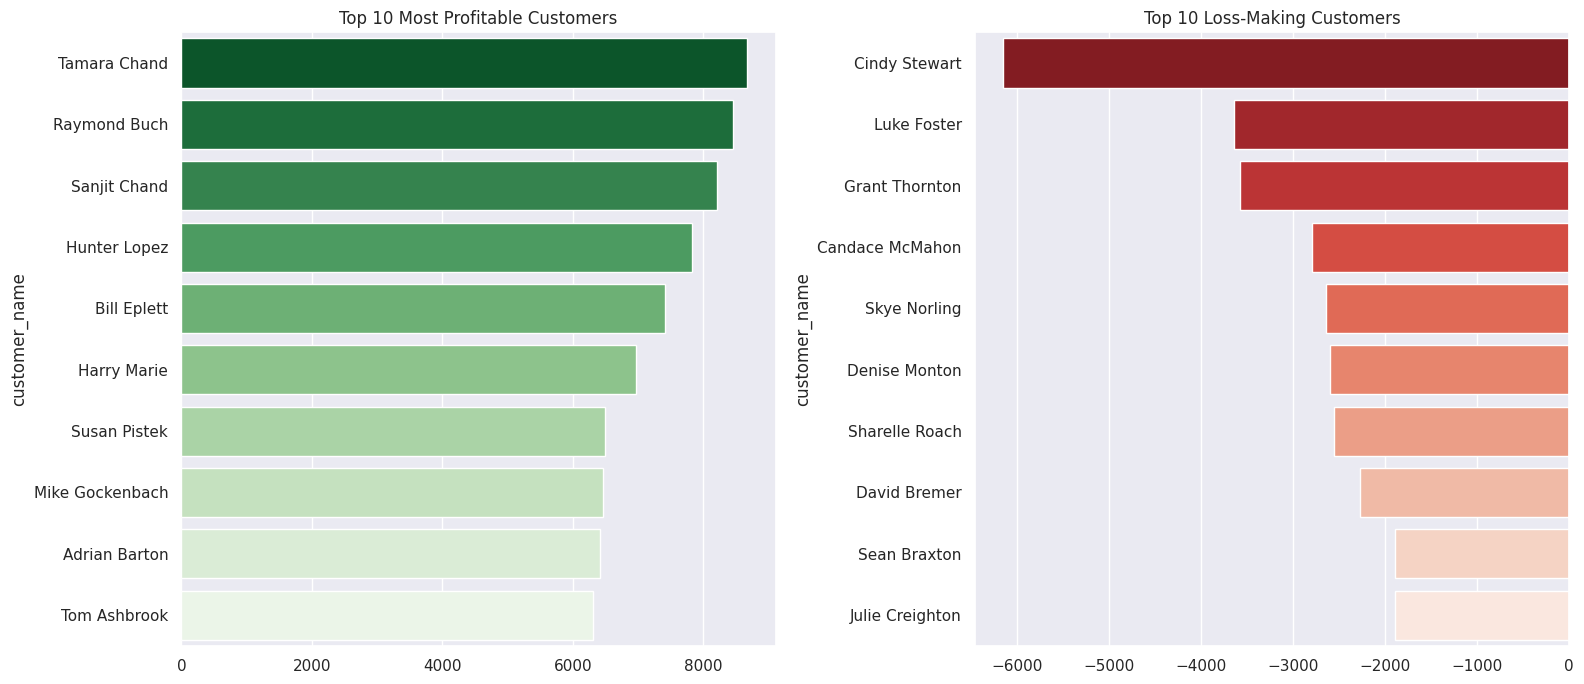

In [33]:
top_customers = df.groupby('customer_name')['profit'].sum().sort_values(ascending=False).head(10)
worst_customers = df.groupby('customer_name')['profit'].sum().sort_values().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(x=top_customers.values, y=top_customers.index, ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10 Most Profitable Customers')
sns.barplot(x=worst_customers.values, y=worst_customers.index, ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 10 Loss-Making Customers')
plt.tight_layout()
plt.show()

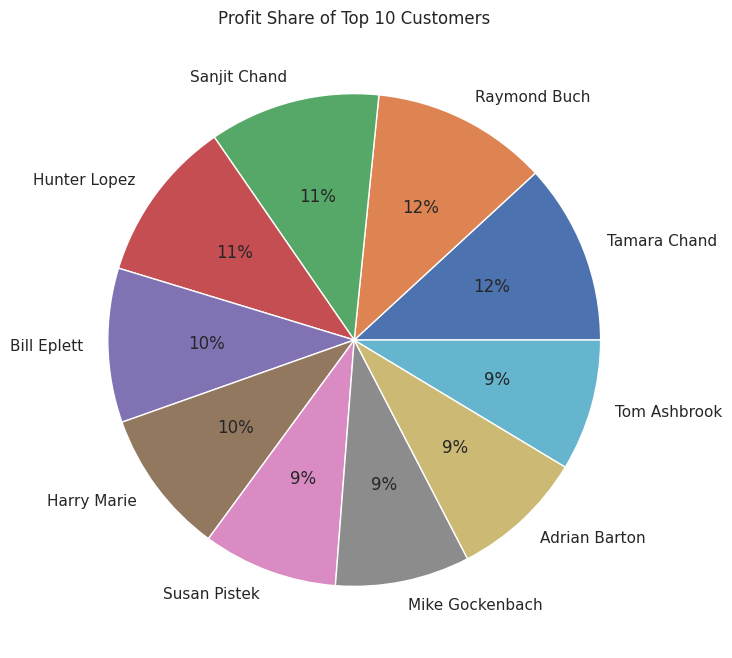

In [34]:

top10 = df.groupby('customer_name')['profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 8))
plt.pie(top10.values, labels=top10.index, autopct='%.0f%%')
plt.title('Profit Share of Top 10 Customers')
plt.show()

Phones drives the highest revenue ($1.7M) despite ranking 6th in order volume — indicating a high average order value strategy, while Binders leads in volume (6,152 orders) with low-ticket sales."

In [35]:
subcat = df.groupby('sub_category')['sales'].sum().sort_values(ascending=False)
subcat

sub_category
Phones         1706874
Copiers        1509439
Chairs         1501682
Bookcases      1466559
Storage        1127124
Appliances     1011081
Machines        779071
Tables          757034
Accessories     749307
Binders         461952
Furnishings     385609
Art             372163
Paper           244307
Supplies        243090
Envelopes       170926
Fasteners        83254
Labels           73433
Name: sales, dtype: int64

# which sub-categories drive the most Revenue?

Phones
Labels


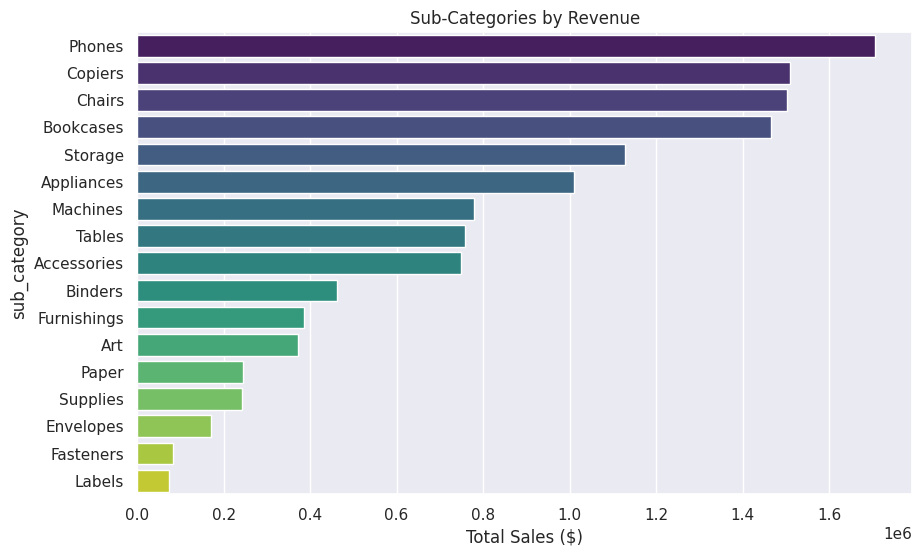

In [36]:
print(df.groupby('sub_category')['sales'].sum().idxmax())  # highest selling subcategory
print(df.groupby('sub_category')['sales'].sum().idxmin())  # lowest selling subcategory

top10_subcat = df.groupby('sub_category')['sales'].sum().sort_values(ascending=False).head(17)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10_subcat.values, y=top10_subcat.index, palette='viridis')
plt.title('Sub-Categories by Revenue')
plt.xlabel('Total Sales ($)')
plt.show()

# Which sub-categories get ordered most often?

sub_category
Binders        6152
Storage        5059
Art            4883
Paper          3538
Chairs         3434
Phones         3357
Furnishings    3170
Accessories    3075
Labels         2606
Envelopes      2435
Supplies       2425
Fasteners      2420
Bookcases      2411
Copiers        2223
Appliances     1755
Machines       1486
Tables          861
Name: count, dtype: int64


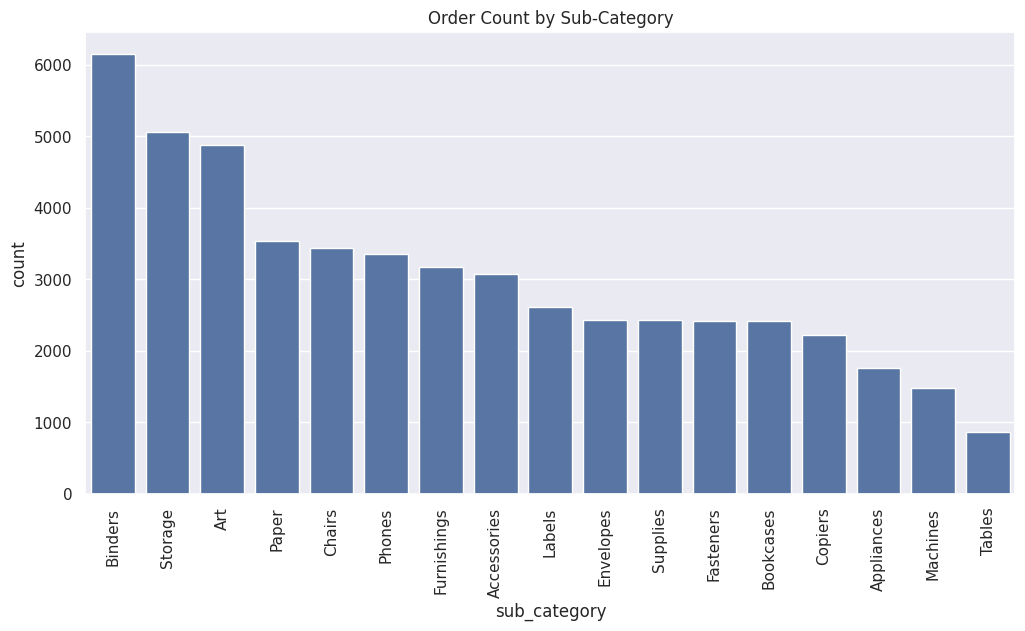

In [37]:
order = df['sub_category'].value_counts().index
print(df['sub_category'].value_counts())
plt.figure(figsize=(12, 6))
sns.countplot(x='sub_category', data=df, order=order)
plt.xticks(rotation=90)
plt.title('Order Count by Sub-Category')
plt.show()

# What share of orders comes from each Sub-Categories?

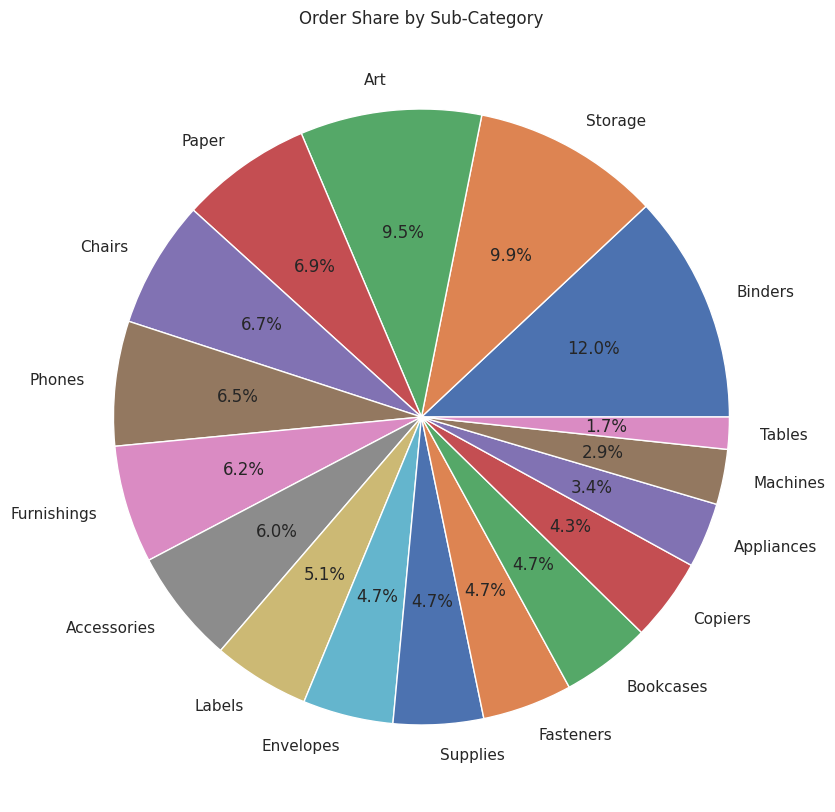

In [38]:
plt.figure(figsize=(15,10))
plt.pie(df['sub_category'].value_counts(),labels=df["sub_category"].value_counts().keys(),autopct="%0.1f%%")
plt.title('Order Share by Sub-Category')
plt.show()

# Which product categories and sub-categories generate the highest sales?

# Which Metrics('sales', 'profit', 'quantity', 'discount', 'shipping_cost', 'Profitability') move together?

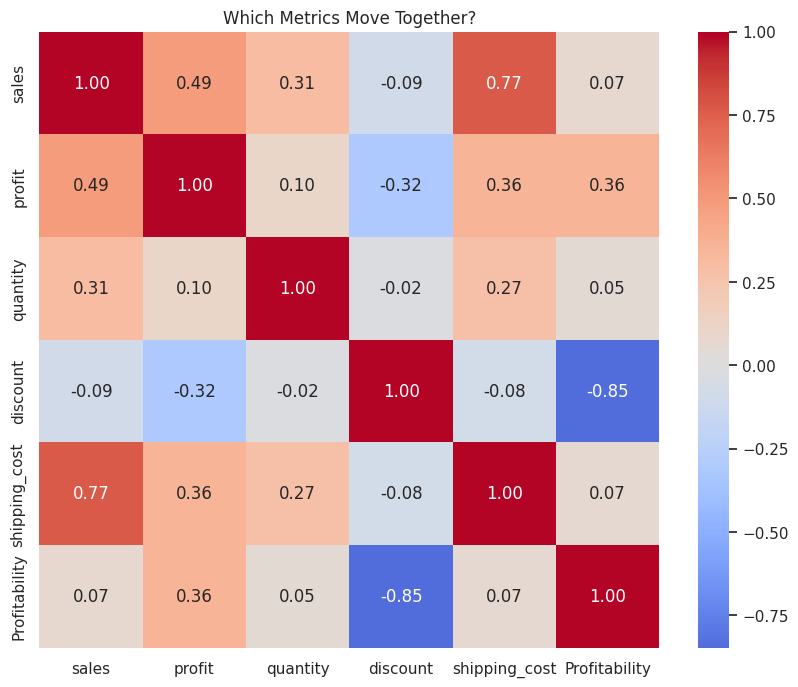

In [39]:
corr_cols = ['sales', 'profit', 'quantity', 'discount', 'shipping_cost', 'Profitability']

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Which Metrics Move Together?')
plt.show()

****"The heatmap confirms discount as the strongest driver of profitability (r = −0.85), while sales alone only moderately predict profit (r = 0.49) — growth without discount control doesn't guarantee earnings."****

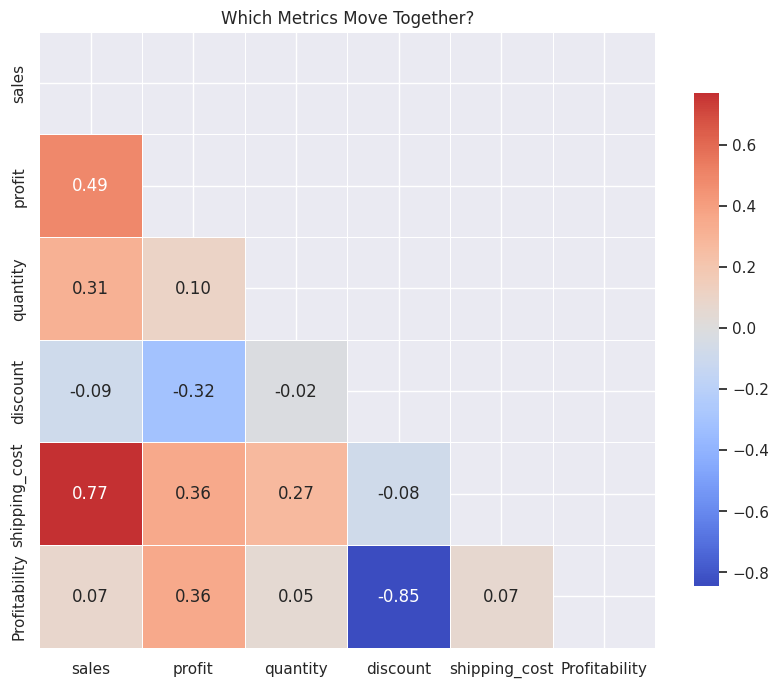

In [40]:
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) 

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Which Metrics Move Together?')
plt.show()

In [41]:
ship_summary = df.groupby('ship_mode').agg(
    orders=('profit', 'count'),
    avg_profit=('profit', 'mean'),
    avg_ship_cost=('shipping_cost', 'mean'),
    avg_days=('Days_took', 'mean')
).round(2)
ship_summary

,orders,avg_profit,avg_ship_cost,avg_days
ship_mode,,,,
First Class,7505,27.73,41.05,2.18
Same Day,2701,28.20,42.94,0.04
Second Class,10309,28.53,30.47,3.23
Standard Class,30775,28.94,19.97,5.00


# Does fast Delivery eat profit?

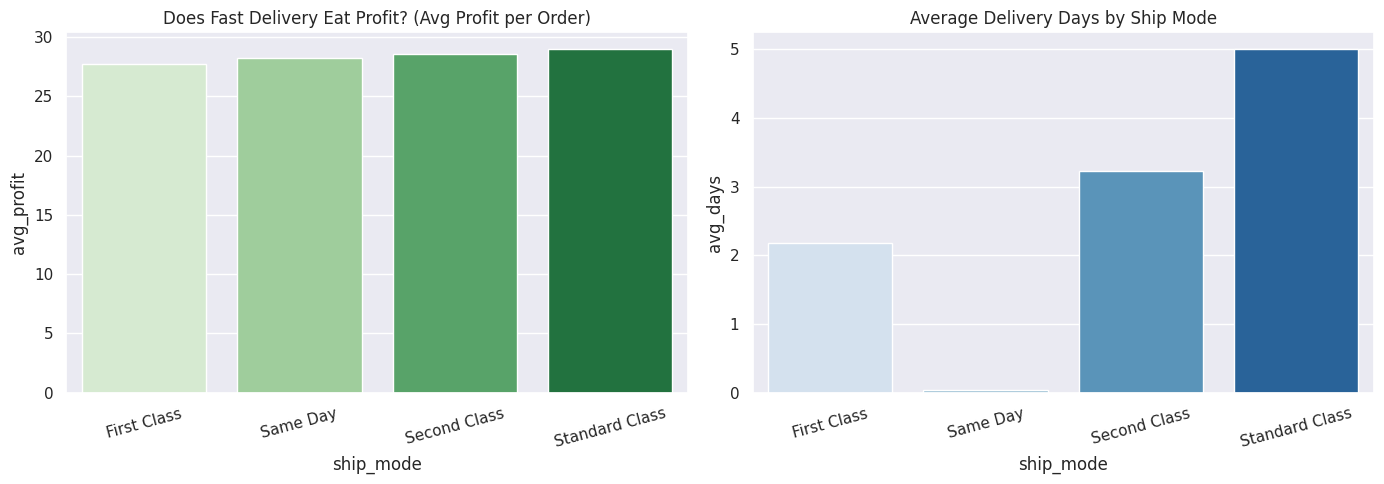

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ship_plot = ship_summary.reset_index()
sns.barplot(data=ship_plot, x='ship_mode', y='avg_profit', hue='ship_mode', legend=False, palette='Greens', ax=axes[0])
axes[0].set_title('Does Fast Delivery Eat Profit? (Avg Profit per Order)')
axes[0].tick_params(axis='x', rotation=15)
sns.barplot(data=ship_plot, x='ship_mode', y='avg_days', hue='ship_mode', legend=False, palette='Blues', ax=axes[1])
axes[1].set_title('Average Delivery Days by Ship Mode')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

****"Same Day shipping costs 2× more per order ($43 vs $20) yet profit per order stays flat (~$28) across all modes — express customers self-select into higher-margin baskets, fully offsetting the delivery premium."****

# How fast are we growing year over year?

In [43]:
yearly = df.groupby('OrderY')[['sales', 'profit']].sum()
yearly['sales_yoy'] = yearly['sales'].pct_change() * 100 #yoy=Year-over-year
yearly['profit_yoy'] = yearly['profit'].pct_change() * 100
yearly.round(1)

,sales,profit,sales_yoy,profit_yoy
OrderY,,,,
2011,2259511,248940.8,NaN,NaN
2012,2677493,307415.3,18.5,23.5
2013,3405860,408512.8,27.2,32.9
2014,4300041,504166.0,26.3,23.4


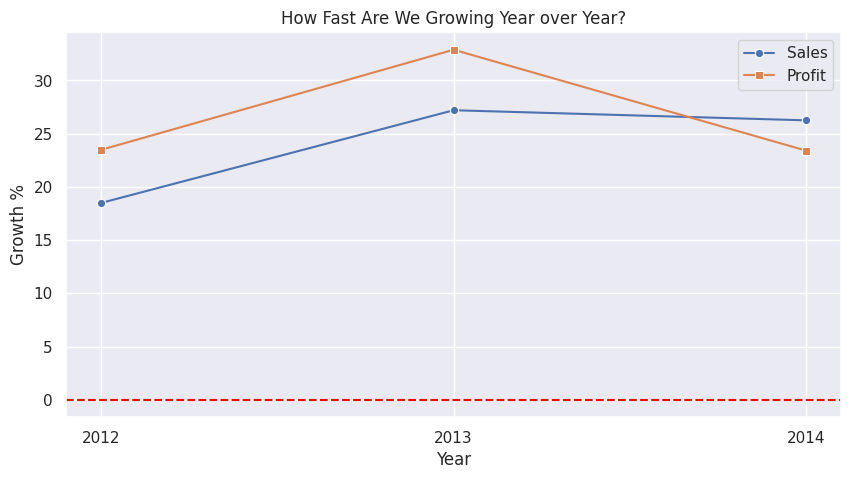

In [44]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=yearly.index, y=yearly['sales_yoy'], marker='o', label='Sales')
sns.lineplot(x=yearly.index, y=yearly['profit_yoy'], marker='s', label='Profit')
plt.axhline(0, color='red', linestyle='--')
plt.title('How Fast Are We Growing Year over Year?')
plt.ylabel('Growth %')
plt.xlabel('Year')
plt.legend()
plt.xticks([2012, 2013, 2014])
plt.show()

In [45]:
df.groupby('OrderY')['discount'].mean()

OrderY
2011    0.148188
2012    0.141286
2013    0.140265
2014    0.143291
Name: discount, dtype: float64

In [46]:
df.groupby('OrderY')['shipping_cost'].mean()

OrderY
2011    27.147264
2012    25.861329
2013    26.418577
2014    26.268197
Name: shipping_cost, dtype: float64

In [47]:
df.groupby(['OrderY', 'category'])['sales'].sum().unstack()

category,Furniture,Office Supplies,Technology
OrderY,,,
2011,756171,675642,827698
2012,858913,795113,1023467
2013,1117739,1010793,1277328
2014,1378061,1305782,1616198


In [48]:
df.groupby(['OrderY', 'market'])['sales'].sum().unstack()

market,APAC,Africa,Canada,EMEA,EU,LATAM,US
OrderY,,,,,,,
2011,639264,127186,8507,136422,478766,385111,484255
2012,762741,144487,16099,163406,655463,464737,470560
2013,974618,229069,19162,204654,761686,608148,608523
2014,1209210,283034,23164,301702,1042224,706691,734016


"Investigated the 2014 profit-growth slowdown across four hypotheses — discounts, shipping costs, category mix, and market mix — and ruled each out with data. The slowdown is primarily a base effect: absolute profit growth held steady at ~$100K/year while the revenue base doubled."

****"Sales nearly doubled from $ 2.3M to $4.3M (2011–2014), with profit growing even faster (+102% vs +90%) — 2013 was the breakout year at +27% sales and +33% profit growth."****

# Which segment is the most profitable?

In [49]:
seg = df.groupby('segment').agg(
    orders=('profit', 'count'),
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    avg_profitability=('Profitability', 'mean')
).round(2)
seg

,orders,total_sales,total_profit,avg_profitability
segment,,,,
Consumer,26518,6508141,749239.78,4.62
Corporate,15429,3824808,442785.86,4.57
Home Office,9343,2309956,277009.18,5.27


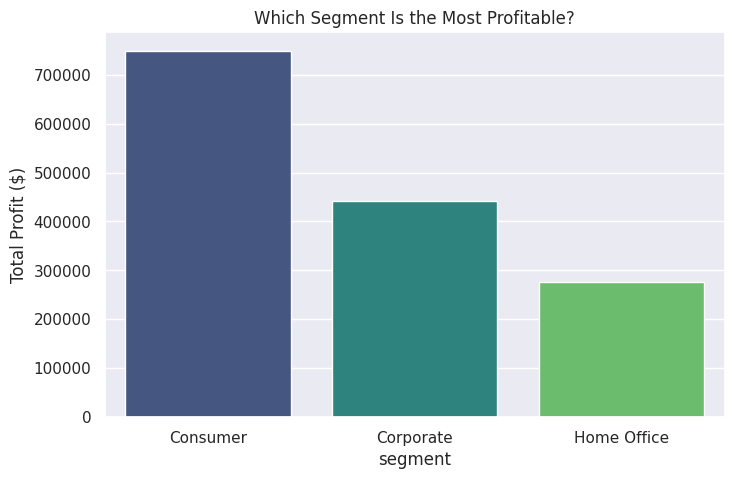

In [50]:
plt.figure(figsize=(8, 5))
sns.barplot(data=seg.reset_index(), x='segment', y='total_profit', hue='segment', legend=False, palette='viridis')
plt.title('Which Segment Is the Most Profitable?')
plt.ylabel('Total Profit ($)')
plt.show()

****"Consumer drives the highest total profit ($749K), but Home Office is the most profitable per order (5.27% avg profitability) — biggest doesn't always mean most efficient."****

# 💸 What do loss-making orders have in common?

In [51]:
df['is_loss'] = df['profit'] < 0
print(f"{df['is_loss'].mean()*100:.1f}% of orders lose money")

df.groupby('is_loss').agg(
    orders=('profit', 'count'),
    avg_discount=('discount', 'mean'),
    avg_sales=('sales', 'mean'),
    avg_ship_cost=('shipping_cost', 'mean')
).round(2)



24.5% of orders lose money


,orders,avg_discount,avg_sales,avg_ship_cost
is_loss,,,,
False,38747,0.04,262.13,28.06
True,12543,0.45,198.23,21.16


In [52]:
df.groupby('category')['is_loss'].mean() * 100

category
Furniture          31.551235
Office Supplies    22.393119
Technology         23.902968
Name: is_loss, dtype: float64

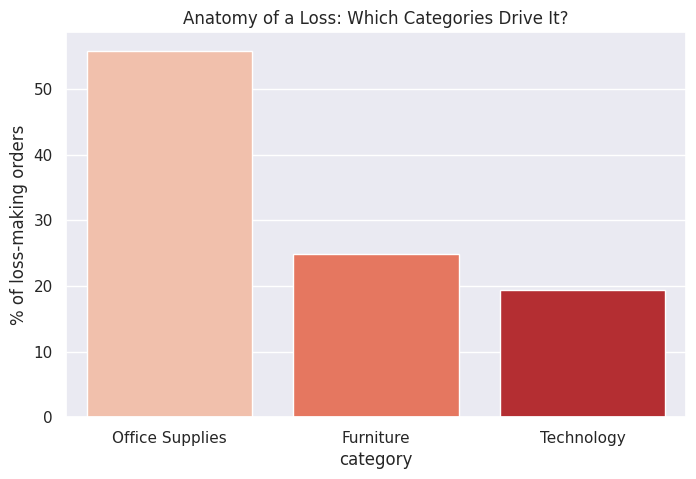

In [53]:
loss_mix = df.query("profit < 0")['category'].value_counts(normalize=True).mul(100).reset_index()
loss_mix.columns = ['category', 'pct']
plt.figure(figsize=(8, 5))
sns.barplot(data=loss_mix, x='category', y='pct', hue='category', legend=False, palette='Reds')
plt.title('Anatomy of a Loss: Which Categories Drive It?')
plt.ylabel('% of loss-making orders')
plt.show()

****"Office Supplies accounts for 55% of all loss-making orders by volume, but Furniture carries the highest per-order loss rate at 31.6% — nearly one in three Furniture orders loses money.the smoking gun is discount: loss-making orders average 45% discount vs just 4% for profitable ones, an 11× gap."****

# Where in the world do our sales come from?

In [54]:
country_sales = df.groupby('country')['sales'].sum().reset_index()

country_profit = df.groupby('country')['profit'].sum().reset_index()
fig2 = px.choropleth(country_profit, locations='country', locationmode='country names',
                     color='profit', color_continuous_scale='RdYlGn',
                     title='Where in the World Do We Actually Make Money?')
fig2.show()

****"Sales are heavily concentrated geographically: the US alone (~$2.3M) dwarfs every other country, with China, India, and Australia forming a distant second tier."****

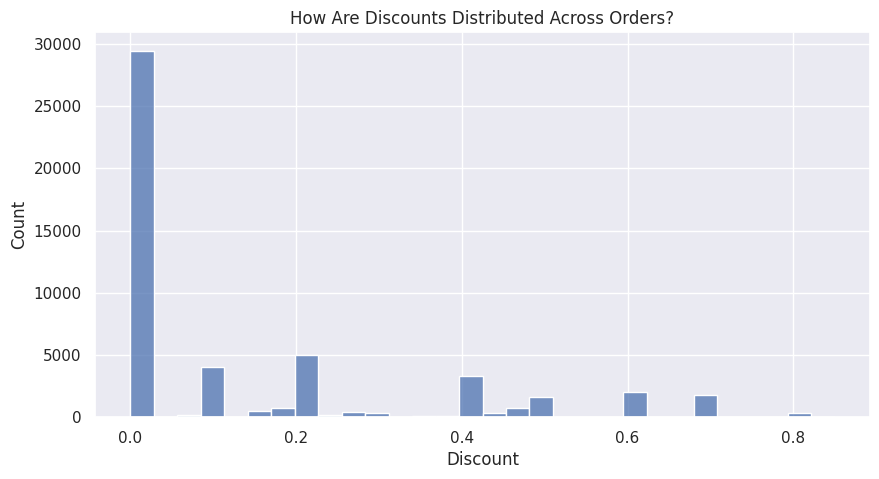

In [55]:
plt.figure(figsize=(10, 5))
sns.histplot(df['discount'], bins=30, kde=False)
plt.title('How Are Discounts Distributed Across Orders?')
plt.xlabel('Discount')
plt.show()


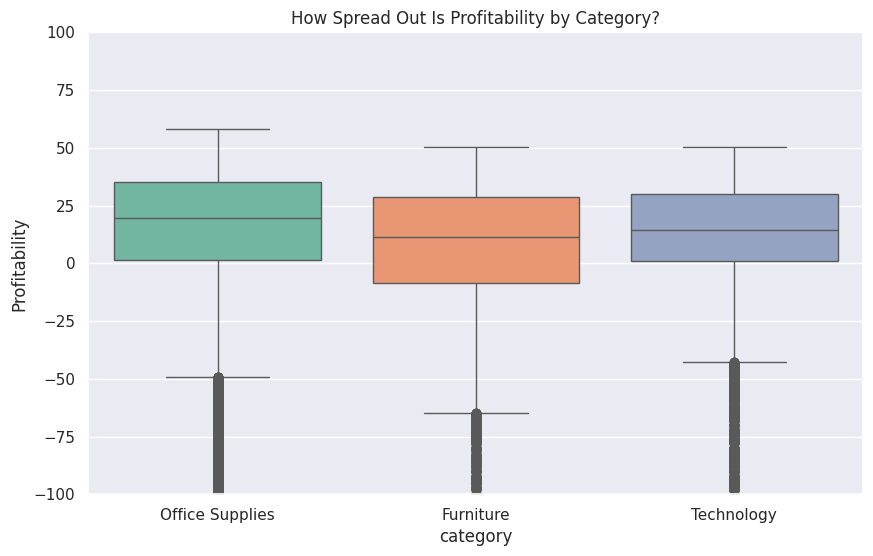

In [56]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='Profitability', hue='category', legend=False, palette='Set2')
plt.ylim(-100, 100)
plt.title('How Spread Out Is Profitability by Category?')
plt.show()

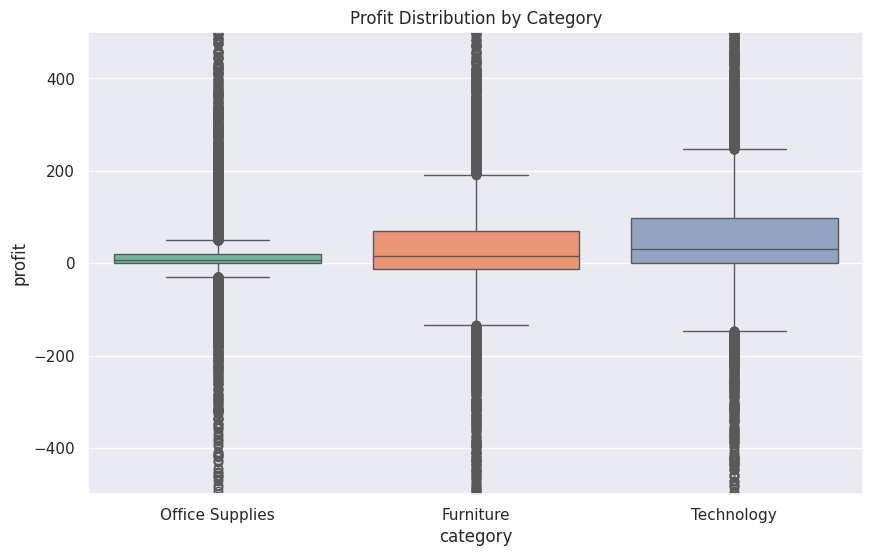

In [57]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='profit', hue='category', legend=False, palette='Set2')
plt.ylim(-500, 500)
plt.title('Profit Distribution by Category')
plt.show()

****Office Supplies is the most efficient per order (20% median profitability) but moves the fewest dollars per order — its thin box hugging zero shows tiny-ticket items; it earns through volume, not per transaction. Technology delivers the biggest dollar profit per order ( about $15 median) with the widest spread reflecting high ticket items with larger swings. 
Furniture trails on both dimensions: the lowest median margin (~12%) with its bottom quartile below zero, and a 31.6% per-order loss rate — nearly one in three Furniture orders loses money.****

# What is the overall trend between discount and profitability?

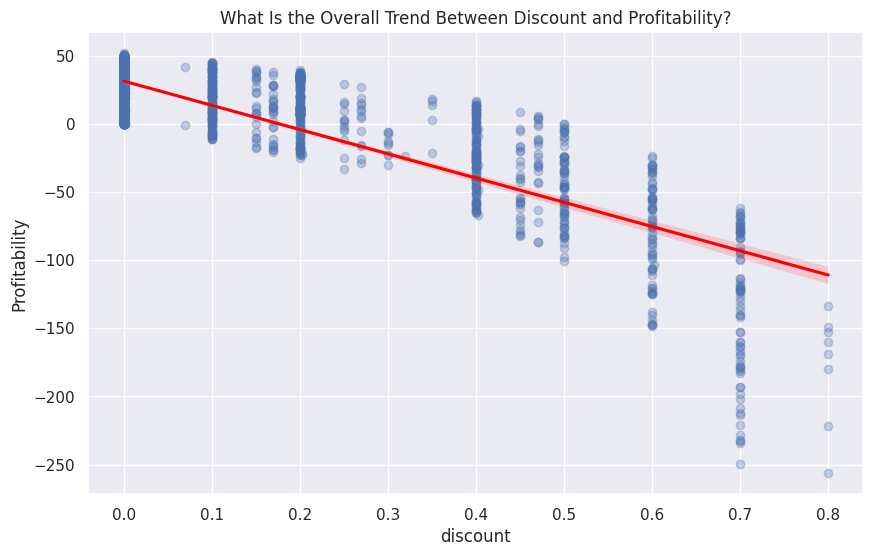

In [58]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df.sample(2000), x='discount', y='Profitability',
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title('What Is the Overall Trend Between Discount and Profitability?')
plt.show()

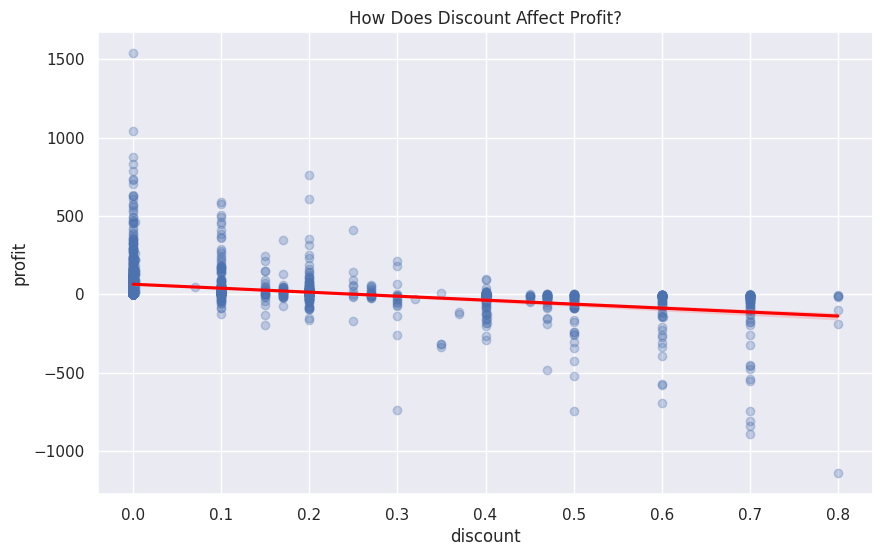

In [59]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df.sample(2000), x='discount', y='profit',
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title('How Does Discount Affect Profit?')
plt.show()

****"Discounts hurt margins (−0.85) far more than dollars (−0.32) — big orders absorb discounts in absolute terms, but their margins still collapse."****

In [60]:
fig = px.treemap(df, path=['category', 'sub_category'], values='sales',
                 color='profit', color_continuous_scale='RdYlGn',
                 title='Revenue (Size) vs Profit (Color) by Sub-Category')
fig.show()

****"Dual-encoding revenue as size and profit as color exposes what single-metric charts hide: Copiers is the profit champion (~$450K) despite its modest size, while Tables is the danger zone — a large tile glowing red, generating revenue but destroying profit."****

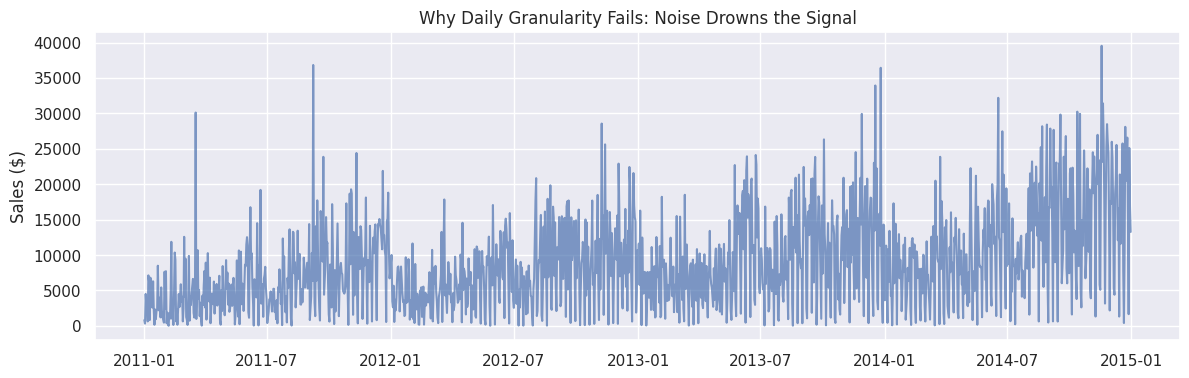

In [61]:
daily = df.groupby(df['order_date'].dt.date)['sales'].sum()
plt.figure(figsize=(14, 4))
plt.plot(daily.index, daily.values, alpha=0.7)
plt.title('Why Daily Granularity Fails: Noise Drowns the Signal')
plt.ylabel('Sales ($)')
plt.show()

# Insights


* Sales nearly doubled 2011–2014 ($2.3M → $4.3M); profit grew even faster (+102% vs +90%).
* 2013 was the breakout year (+27% sales, +33% profit); 2014 profit growth lagged due to base effect.
* Technology was the most profitable category; Phones drove the most revenue ($1.7M) despite ranking 6th in volume.
* Copiers was the hidden profit champion ($450K); Tables was the danger zone (big revenue, negative profit).
* Binders led order volume (6,152 orders) with lower-ticket sales — volume ≠ revenue.
*  The US generated the highest sales (~$2.3M); Canada and EMEA were loss-making markets.
* Consumer drove the most total profit ($749K); Home Office was the most profitable per order (5.27%).
* Discount is the #1 profit killer (correlation −0.85); break-even at 20–30% discount. * 24.5% of orders lost money — averaging 45% discount vs 4% for profitable ones (11× gap).
* Fast delivery did not eat profit: ~$28/order across all ship modes despite 2× shipping costs.



# Business Recommendations

* Cap discounts at 20%; require manual review above 30%.
*  Fix or exit Tables — reprice or cut discounts on consistent losers.
* Investigate Canada & EMEA — reprice, reduce exposure, or withdraw.
*  Protect Copiers and Phones — priority in marketing and inventory.
*  Alert on at-risk orders — flag predicted loss-makers before they ship.
*  Learn from Home Office — replicate its per-order efficiency in other segments.
* Set system guardrails — encode discount and margin thresholds into order management.